# Import data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the CSV data
df = pd.read_csv('test_comparaison_cnn_results.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nModels: {df['model_name'].unique()}")
print(f"\nFirst few rows:")
df.head()

Data loaded successfully!
Shape: (500, 5)

Columns: ['model_name', 'episode', 'survival_time', 'zombies_killed', 'wave_achieved']

Models: ['best_model' 'best_model_stay_up_1' 'best_model_stay_up_2'
 'best_model_stay_up_4' 'checkpoint_550912_113killed_wave12_3']

First few rows:


,model_name,episode,survival_time,zombies_killed,wave_achieved
0,best_model,1,1288,23,2
1,best_model,2,460,7,1
2,best_model,3,2504,46,5
3,best_model,4,1383,24,3
4,best_model,5,3726,72,8


In [5]:
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

In [6]:
FILE_PATH = "test_comparaison_cnn_results.csv"  # Change this to your file path

df = pd.read_csv(FILE_PATH)
print(df['model_name'].unique())

df.head()

['best_model' 'best_model_stay_up_1' 'best_model_stay_up_2'
 'best_model_stay_up_4' 'checkpoint_550912_113killed_wave12_3']


,model_name,episode,survival_time,zombies_killed,wave_achieved
0,best_model,1,1288,23,2
1,best_model,2,460,7,1
2,best_model,3,2504,46,5
3,best_model,4,1383,24,3
4,best_model,5,3726,72,8


# descriptive statistics

In [7]:
import pandas as pd

metrics = ['survival_time', 'zombies_killed', 'wave_achieved']

# Containers for each metric
survival_stats = []
zombies_stats = []
wave_stats = []

for model in sorted(df['model_name'].unique()):
    model_data = df[df['model_name'] == model]
    
    for metric in metrics:
        data = model_data[metric]
        
        stats_dict = {
            'Model': model,
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'IQR': data.quantile(0.75) - data.quantile(0.25)
        }
        
        if metric == 'survival_time':
            survival_stats.append(stats_dict)
        elif metric == 'zombies_killed':
            zombies_stats.append(stats_dict)
        elif metric == 'wave_achieved':
            wave_stats.append(stats_dict)

# Create DataFrames
df_survival_time = pd.DataFrame(survival_stats)
df_zombies_killed = pd.DataFrame(zombies_stats)
df_wave_achieved = pd.DataFrame(wave_stats)


In [8]:
print("Survival Time Summary:")
df_survival_time

Survival Time Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model,2234.52,2251.0,1089.672469,80,5108,1370.25,3024.75,1654.5
1,best_model_stay_up_1,2278.59,2429.5,1069.288512,80,4706,1470.75,3060.25,1589.5
2,best_model_stay_up_2,2154.98,2352.0,1099.127487,87,5103,1259.25,2990.25,1731.0
3,best_model_stay_up_4,2248.06,2497.5,1087.618182,97,4902,1418.00,2988.00,1570.0
4,checkpoint_550912_113killed_wave12_3,2506.54,2778.0,1265.889310,117,5218,1497.00,3264.00,1767.0


In [9]:
print("Zombies Killed Summary:")
df_zombies_killed

Zombies Killed Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model,42.76,42.5,22.887569,0,108,24.0,59.25,35.25
1,best_model_stay_up_1,44.02,45.5,23.136826,0,107,25.0,60.25,35.25
2,best_model_stay_up_2,41.44,44.0,23.340830,1,113,22.0,59.00,37.00
3,best_model_stay_up_4,42.85,47.5,22.433459,1,102,25.0,59.00,34.00
4,checkpoint_550912_113killed_wave12_3,49.36,52.0,28.197543,1,131,26.0,66.00,40.00


In [10]:
print("Wave Achieved Summary:")
df_wave_achieved

Wave Achieved Summary:


,Model,Mean,Median,Std,Min,Max,Q1,Q3,IQR
0,best_model,4.75,5.0,2.337118,1,11,3.0,6.0,3.0
1,best_model_stay_up_1,4.84,5.0,2.360106,1,11,3.0,6.0,3.0
2,best_model_stay_up_2,4.63,5.0,2.381134,1,12,3.0,6.0,3.0
3,best_model_stay_up_4,4.71,5.0,2.284312,1,11,3.0,6.0,3.0
4,checkpoint_550912_113killed_wave12_3,5.31,6.0,2.873406,1,14,3.0,7.0,4.0


# Fiding the best parameters to test on

## Correlation test (pearson & spearman)

In [11]:
metrics = ['survival_time', 'zombies_killed', 'wave_achieved']
correlation_results = []

for i, metric1 in enumerate(metrics):
    for metric2 in metrics[i+1:]:
        corr, p_value = pearsonr(df[metric1], df[metric2])
        correlation_results.append({
            'Metric 1': metric1,
            'Metric 2': metric2,
            'Correlation Type': 'Pearson',
            'Correlation': corr,
            'p_value': p_value
        })

for i, metric1 in enumerate(metrics):
    for metric2 in metrics[i+1:]:
        corr, p_value = spearmanr(df[metric1], df[metric2])
        correlation_results.append({
            'Metric 1': metric1,
            'Metric 2': metric2,
            'Correlation Type': 'Spearman',
            'Correlation': corr,
            'p_value': p_value
        })
        

corr_df = pd.DataFrame(correlation_results)
corr_df

,Metric 1,Metric 2,Correlation Type,Correlation,p_value
0,survival_time,zombies_killed,Pearson,0.990394,0.000000e+00
1,survival_time,wave_achieved,Pearson,0.972489,2.895844e-317
2,zombies_killed,wave_achieved,Pearson,0.983296,0.000000e+00
3,survival_time,zombies_killed,Spearman,0.996376,0.000000e+00
4,survival_time,wave_achieved,Spearman,0.977134,0.000000e+00
5,zombies_killed,wave_achieved,Spearman,0.980779,0.000000e+00


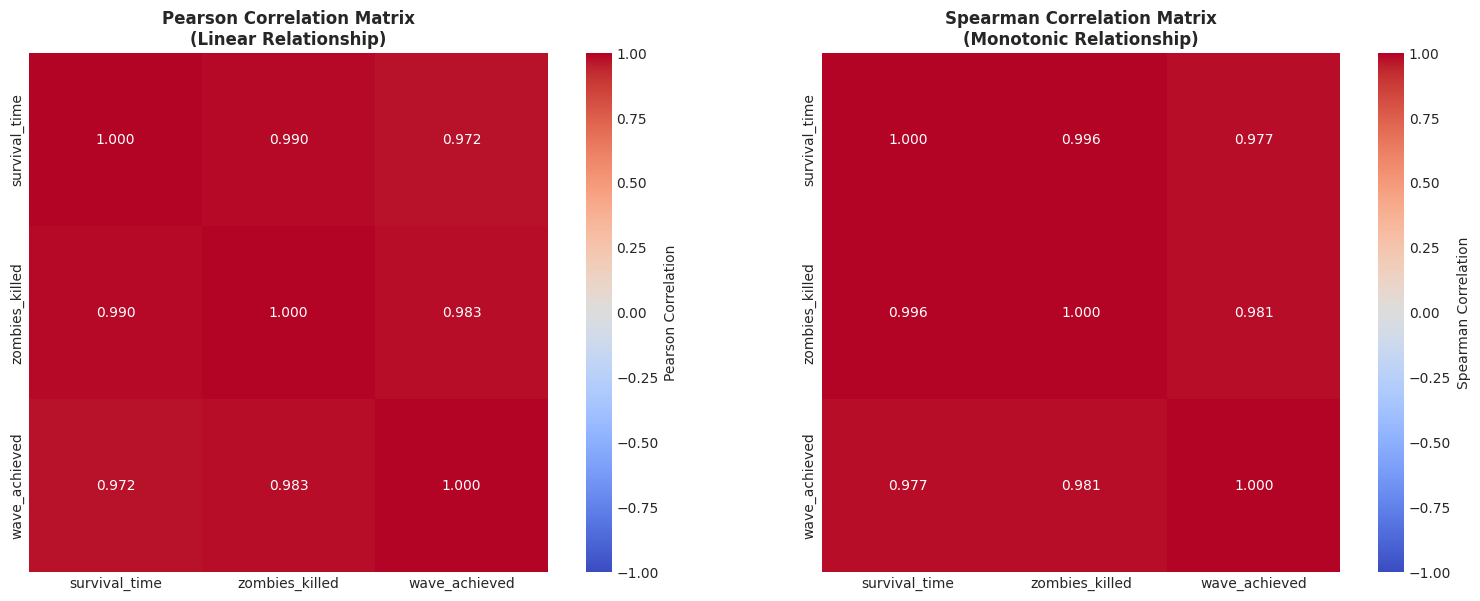

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation heatmap
corr_matrix_pearson = df[metrics].corr(method='pearson')
sns.heatmap(corr_matrix_pearson, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Pearson Correlation Matrix\n(Linear Relationship)', 
                  fontsize=12, fontweight='bold')

# Spearman correlation heatmap
corr_matrix_spearman = df[metrics].corr(method='spearman')
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True,
            cbar_kws={'label': 'Spearman Correlation'})
axes[1].set_title('Spearman Correlation Matrix\n(Monotonic Relationship)', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

we will do test on the survival_time

# STatical test

## Normality test (shapiro)

In [13]:
from scipy.stats import shapiro, kruskal, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import scikit_posthocs as sp

METRIC = 'survival_time'

In [17]:
print("Shapiro-Wilk")

normality_results = []
all_normal = True

for model in sorted(df['model_name'].unique()):
    model_data = df[df['model_name'] == model][METRIC].values
    stat, p_value = shapiro(model_data)
    is_normal = p_value > 0.05
    
    if not is_normal:
        all_normal = False
    
    normality_results.append({
        'Model': model,
        'Statistic': stat,
        'p_value': p_value,
        'Normal?': 'Yes' if is_normal else 'No'
    })
    

normality_df = pd.DataFrame(normality_results)
normality_df


Shapiro-Wilk


,Model,Statistic,p_value,Normal?
0,best_model,0.983935,0.265449,Yes
1,best_model_stay_up_1,0.981848,0.184719,Yes
2,best_model_stay_up_2,0.964741,0.008884,No
3,best_model_stay_up_4,0.978853,0.108158,Yes
4,checkpoint_550912_113killed_wave12_3,0.965223,0.009645,No


At least one group is not normal -> Will use Kruskal-Wallis (non-parametric)

## Kruskal-Wallis Test (Non-Parametric Alternative to ANOVA)
Since data is not normally distributed, we use Kruskal-Wallis test to determine if there are significant differences between models.

In [19]:
print("\n" + "="*80)
print("KRUSKAL-WALLIS TEST (Non-Parametric)")
print("="*80)
print("H0: All groups have the same distribution (no significant difference)")
print("H1: At least one group is different")
print("If p < 0.05: Reject H0 → Significant difference exists between groups")
print("="*80)

# Prepare data for each model
groups = []
model_names = sorted(df['model_name'].unique())

for model in model_names:
    groups.append(df[df['model_name'] == model][METRIC].values)

# Perform Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print(f"\nTest Statistic (H): {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {len(model_names) - 1}")


KRUSKAL-WALLIS TEST (Non-Parametric)
H0: All groups have the same distribution (no significant difference)
H1: At least one group is different
If p < 0.05: Reject H0 → Significant difference exists between groups

Test Statistic (H): 5.6991
p-value: 0.222776
Degrees of freedom: 4


In [22]:
# Interpret the result
if p_value < 0.05:
    print(f"RESULT: p-value = {p_value:.6f} < 0.05 → Significant difference exists between models!")
else:
    print(f"RESULT: p-value = {p_value:.6f} >= 0.05 → No significant difference between models")

RESULT: p-value = 0.222776 >= 0.05 → No significant difference between models


so we will choose based on the descriptive statistics,
teh best cnn model is 'checkpoint_550912_113killed_wave12_3.pth'